In [1]:
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt


In [2]:
REPO_ROOT = Path.cwd().resolve()
if REPO_ROOT.name == "notebooks":
    REPO_ROOT = REPO_ROOT.parent

data_file = REPO_ROOT / "data" / "aqmola" / "Akmola_S1_patchmean_20m_10d_20180101_20181231.csv"
eu_data_file = REPO_ROOT / "data" / "prepared" / "S1_point_all_10d_10m_20180101-20180731_Stratum1_VV-VH.csv"
target_crop = "пшеница"
target_crop_label = "Wheat"
common_wheat_level2 = 211


In [3]:
df = pd.read_csv(data_file)
eu_df = pd.read_csv(eu_data_file, dtype={"level_1": int, "level_2": int})
print(f"Loaded Akmola dataset with shape {df.shape}")
print(f"Loaded EU reference dataset with shape {eu_df.shape}")

wheat_df = df[df["crop"] == target_crop].copy()
common_wheat_df = eu_df[eu_df["level_2"] == common_wheat_level2].copy()
print(f"Rows for '{target_crop}': {len(wheat_df)}")
print(f"Rows for common wheat (level_2={common_wheat_level2}): {len(common_wheat_df)}")

if wheat_df.empty:
    raise ValueError(f"No rows found for crop '{target_crop}' in {data_file.name}")

if common_wheat_df.empty:
    raise ValueError(f"No common wheat rows found in {eu_data_file.name}")

wheat_df.head()


Loaded Akmola dataset with shape (276, 76)
Loaded EU reference dataset with shape (1743815, 46)
Rows for 'пшеница': 205
Rows for common wheat (level_2=211): 195821


,system:index,POINT_ID,VH_20180101,VH_20180111,VH_20180121,VH_20180131,VH_20180210,VH_20180220,VH_20180302,VH_20180312,...,VV_20181008,VV_20181018,VV_20181028,VV_20181107,VV_20181117,VV_20181127,VV_20181207,VV_20181217,crop,.geo
2,2,3,-27.798090,-27.679118,-28.133330,-29.148294,-27.957370,-27.940629,-26.798706,NaN,...,-12.732779,-14.602498,-14.003636,-16.423607,-15.603823,-14.041686,-14.938399,-15.405555,пшеница,"{""type"":""Polygon"",""coordinates"":[[[71.909225,5..."
3,3,4,-26.918339,-27.563789,-26.898372,-28.211080,-26.871760,-26.935709,-25.298772,NaN,...,-14.154438,-14.220107,-15.808688,-17.668032,-16.645731,-14.937142,-15.887496,-16.327213,пшеница,"{""type"":""Polygon"",""coordinates"":[[[71.920071,5..."
4,4,5,-27.388152,-28.421644,-27.375149,-28.176115,-27.218853,-27.194937,-25.867921,NaN,...,-13.380488,-14.523956,-15.020289,-17.130712,-16.205642,-15.253305,-15.987387,-16.331146,пшеница,"{""type"":""Polygon"",""coordinates"":[[[71.919362,5..."
5,5,6,-27.749722,-27.980013,-27.281837,-27.495100,-26.814774,-27.615918,-25.861770,NaN,...,-12.208740,-14.112586,-14.844912,-17.424378,-16.952843,-15.367705,-16.361365,-16.614232,пшеница,"{""type"":""Polygon"",""coordinates"":[[[71.918589,5..."
6,6,7,-24.986683,-26.325085,-24.933492,-24.090482,-24.976402,-25.310925,-23.958164,NaN,...,-13.654991,-14.201286,-13.862813,-15.310076,-14.679826,-14.485600,-14.725909,-15.323804,пшеница,"{""type"":""Polygon"",""coordinates"":[[[72.018904,5..."


In [4]:
vv_columns = [col for col in wheat_df.columns if col.startswith("VV_") and col.split("_", 1)[1] <= "20180720"]
eu_vv_columns = [col for col in common_wheat_df.columns if col.startswith("VV_") and col.split("_", 1)[1] <= "20180720"]

vv_labels = [col.split("_", 1)[1] for col in vv_columns]
plot_labels = [f"{label[4:6]}-{label[6:8]}" for label in vv_labels]
month_names = ["Jan", "Feb", "Mar", "Apr", "May", "Jun", "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]
tick_count = min(6, len(vv_labels))
tick_positions = [round(i * (len(vv_labels) - 1) / (tick_count - 1)) for i in range(tick_count)] if tick_count > 1 else [0]
tick_labels = [f"{month_names[int(vv_labels[i][4:6]) - 1]} {int(vv_labels[i][6:8])}" for i in tick_positions]

vv_data = wheat_df[vv_columns].apply(pd.to_numeric, errors="coerce")
eu_vv_data = common_wheat_df[eu_vv_columns].apply(pd.to_numeric, errors="coerce")

vv_mean = vv_data.mean()
eu_vv_mean = eu_vv_data.mean()

mean_curves = pd.DataFrame({
    "date": plot_labels,
    "Akmola_VV_mean": vv_mean.values,
    "EU_common_wheat_VV_mean": eu_vv_mean.values,
})
mean_curves


,date,Akmola_VV_mean,EU_common_wheat_VV_mean
0,01-01,-16.036813,-8.729834
1,01-11,-16.111201,-10.294926
2,01-21,-16.118000,-9.523081
3,01-31,-15.866931,-10.342842
4,02-10,-16.908946,-11.105093
5,02-20,-16.076054,-12.682183
6,03-02,-15.061900,-11.135361
7,03-12,-13.429415,-10.321410
8,03-22,-13.051015,-10.253671
9,04-01,-12.685617,-10.210037


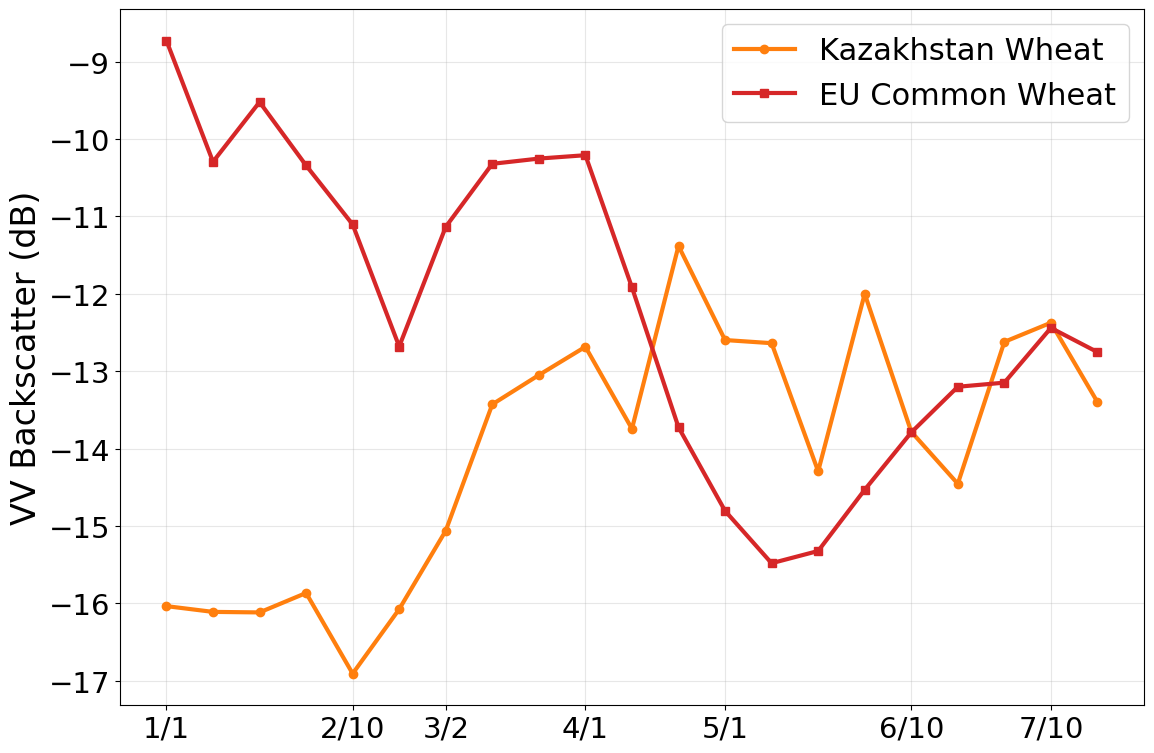

In [5]:
plt.rcParams.update({
    "font.size": 22,
    "axes.labelsize": 24,
    "xtick.labelsize": 21,
    "ytick.labelsize": 21,
    "legend.fontsize": 22,
})

x = range(len(plot_labels))
fig, ax = plt.subplots(figsize=(12, 8))

ax.plot(x, vv_mean, marker="o", linewidth=3, color="tab:orange", label=f"Kazakhstan {target_crop_label}")
ax.plot(x, eu_vv_mean, marker="s", linewidth=3, color="tab:red", label="EU Common Wheat")
ax.set_ylabel("VV Backscatter (dB)")
ax.grid(True, alpha=0.3)
ax.legend()

plt.xticks(tick_positions, tick_labels)
plt.tight_layout()
plt.show()
